## 16 - read clean data
## 17 - design NN (proplem classification)
## 18 - prepeare NN
## 19 - traning NN
## 20 - Evalution

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow
import seaborn as sns
from sklearn.metrics import classification_report , roc_curve, auc , confusion_matrix 
from keras.models import Sequential
from keras.layers import Dense , Input
from keras.optimizers import Adam
from keras.losses import BinaryCrossentropy
from keras.metrics import Accuracy
from keras.callbacks import EarlyStopping , ReduceLROnPlateau      

In [3]:
X_train = np.load('X_train_processed.npy')
X_test  = np.load('X_test_processed.npy')
y_train = np.load('y_train.npy')
y_test  = np.load('y_test.npy')

print(X_train.shape)
print(X_test.shape)

(138804, 9)
(19048, 9)


## 17 - design NN (proplem classification)

In [4]:
nn_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128 , activation='relu'),
    Dense(64, activation='relu'),
    Dense(32 , activation='relu'),
    Dense(1 , activation='sigmoid')

])

## 18 - prepeare NN

In [5]:
nn_model.compile(optimizer=Adam() , loss= BinaryCrossentropy() , metrics=[Accuracy()])

In [6]:
early_stoping = EarlyStopping(monitor='val_loss' , patience=10 , restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      
    patience=5,      
    min_lr=1e-6,     
    verbose=1        
)

## traning NN

In [7]:
history = nn_model.fit(
    X_train ,
    y_train ,
    validation_split=0.2 ,
    epochs=100 ,
    batch_size=32 , 
    callbacks=[early_stoping , reduce_lr]
)

Epoch 1/100
3471/3471 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.0392 - loss: 0.2030 - val_accuracy: 0.3481 - val_loss: 0.3051 - learning_rate: 0.0010
Epoch 2/100
3471/3471 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.1592 - loss: 0.1785 - val_accuracy: 0.4855 - val_loss: 0.1902 - learning_rate: 0.0010
Epoch 3/100
3471/3471 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.1886 - loss: 0.1735 - val_accuracy: 0.5242 - val_loss: 0.2097 - learning_rate: 0.0010
Epoch 4/100
3471/3471 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.1978 - loss: 0.1710 - val_accuracy: 0.5445 - val_loss: 0.2318 - learning_rate: 0.0010
Epoch 5/100
3471/3471 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.2031 - loss: 0.1690 - val_accuracy: 0.5577 - val_loss: 0.2078 - learning_rate: 0.0010
Epoch 6/100
3471/3471 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.2149 - loss: 0.1663 - val_accuracy: 0.5529 - val_loss: 0.2351 - learning_rate: 0.0010
Epoch 7/100
3462/3471 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy:

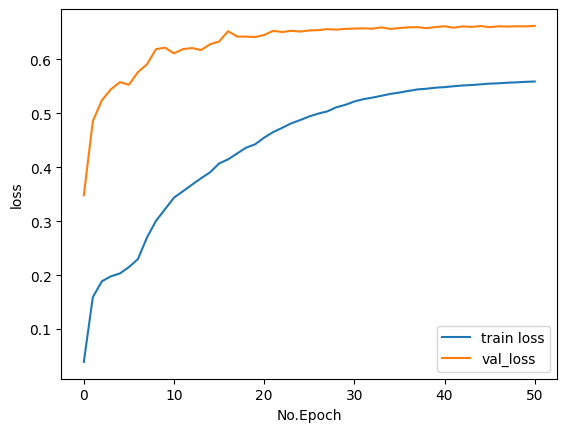

In [8]:
plt.plot(history.history['accuracy'] , label='train loss')
plt.plot(history.history['val_accuracy'] , label= 'val_loss')
plt.xlabel('No.Epoch')
plt.ylabel('loss')
plt.legend()

In [9]:
y_pred = nn_model.predict(X_test)
y_pred = (nn_model.predict(X_test) >= 0.6).astype(int)
y_pred


596/596 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
596/596 ━━━━━━━━━━━━━━━━━━━━ 1s 924us/step


array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(19048, 1))

In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97     17352
           1       0.66      0.79      0.72      1696

    accuracy                           0.94     19048
   macro avg       0.82      0.87      0.84     19048
weighted avg       0.95      0.94      0.95     19048



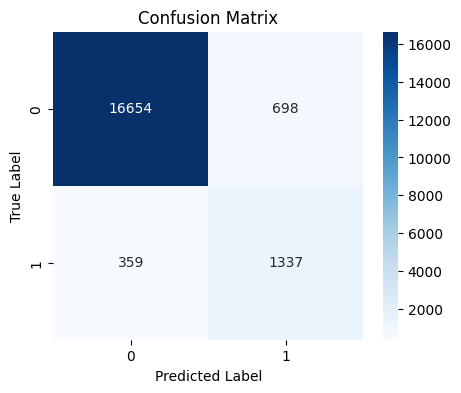

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show() 

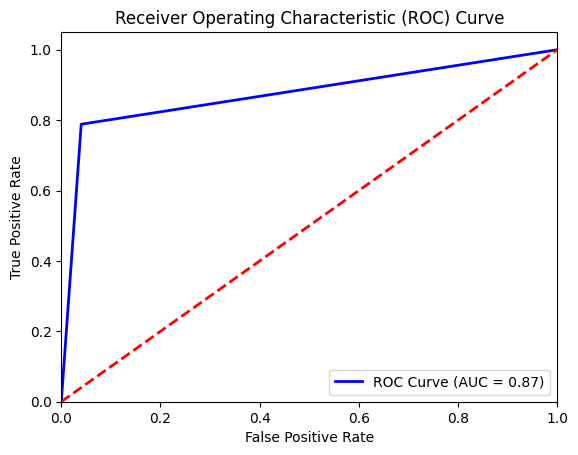

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()